In [101]:
import pandas as pd
import numpy as np
pd.options.display.max_rows = 1000
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, StratifiedShuffleSplit
from sklearn.model_selection import permutation_test_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pickle
import os
from collections import Counter

import sys
sys.path.append("../../code")
import interpretability

In [115]:
response_var = "remitter"
response_var_cap = "Remitter"
conditions = "mdd_dyna_wexp"
conditions_cap = "MDD Dynamix Expert Weights"
eval_metric = "nppv"
eval_metric_cap = "nPPV"

In [103]:
# load in dynamix data
df_dynamix = pd.read_pickle('../../data/dynamix_ec_wexp_all.pkl')
# df_dynamix = pd.read_pickle('../../data/dynamix_ec_all.pkl')
print("Dynamix dataframe shape:", df_dynamix.shape) # subjects x num_dynamix_ftrs
print(df_dynamix.head())

Dynamix dataframe shape: (120, 81)
  participants_ID  dynamix_ec_std_1  dynamix_ec_std_2  dynamix_ec_std_3  \
0    sub-87999321      4.307209e-07          0.007910          0.032557   
1    sub-88000181      1.720614e-07          0.004325          0.018321   
2    sub-88000313      3.648407e-07          0.005574          0.021036   
3    sub-88000489      8.692808e-06          0.005777          0.021002   
4    sub-88000533      3.237152e-07          0.005321          0.024458   

   dynamix_ec_std_4  dynamix_ec_std_5  dynamix_ec_std_6  dynamix_ec_std_7  \
0          0.008380          0.004189      4.800891e-07          0.010122   
1          0.008734          0.004277      1.897044e-07          0.009725   
2          0.010330          0.005392      4.427909e-07          0.008924   
3          0.005398          0.002424      1.207028e-05          0.005063   
4          0.025878          0.015201      4.022615e-07          0.030688   

   dynamix_ec_std_8  dynamix_ec_std_9  ...  dynamix

### Merge dataframes

In [104]:
demographic_df = pd.read_csv(f"../../data/final_dataset_{response_var}.csv")
demographic_df.head()
print("Demographic dataframe shape:", demographic_df.shape)

duplicate_ids = demographic_df["participants_ID"].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1].index
demographic_df = demographic_df.drop_duplicates(subset="participants_ID", keep="first")
print("Shape after keeping only first entry for each participant for demographic_df:", demographic_df.shape)

df = pd.merge(df_dynamix, demographic_df, on='participants_ID', how='inner')
print("Merged dataframe shape:", df.shape)
print(df.head())

Demographic dataframe shape: (226, 114)
Shape after keeping only first entry for each participant for demographic_df: (211, 114)
Merged dataframe shape: (120, 194)
  participants_ID  dynamix_ec_std_1  dynamix_ec_std_2  dynamix_ec_std_3  \
0    sub-87999321      4.307209e-07          0.007910          0.032557   
1    sub-88000181      1.720614e-07          0.004325          0.018321   
2    sub-88000313      3.648407e-07          0.005574          0.021036   
3    sub-88000489      8.692808e-06          0.005777          0.021002   
4    sub-88000533      3.237152e-07          0.005321          0.024458   

   dynamix_ec_std_4  dynamix_ec_std_5  dynamix_ec_std_6  dynamix_ec_std_7  \
0          0.008380          0.004189      4.800891e-07          0.010122   
1          0.008734          0.004277      1.897044e-07          0.009725   
2          0.010330          0.005392      4.427909e-07          0.008924   
3          0.005398          0.002424      1.207028e-05          0.005063   


### Preprocessing & splitting

In [105]:
cols = ['age', 'gender', 'BDI_pre']
dynamix_cols = df.filter(regex='dynamix_').columns.tolist()
# print(dynamix_cols)

# construct X
X = df[cols + dynamix_cols]
y = df[response_var_cap]

# binary vars float --> str
X = X.copy()
X['gender'] = X['gender'].map({1.0: 'male', 0.0: 'female'})

print("X shape:", X.shape)
print("X columns:", X.columns)
# print("X column datatypes:", X.dtypes)
print(X.head())

X shape: (120, 83)
X columns: Index(['age', 'gender', 'BDI_pre', 'dynamix_ec_std_1', 'dynamix_ec_std_2',
       'dynamix_ec_std_3', 'dynamix_ec_std_4', 'dynamix_ec_std_5',
       'dynamix_ec_std_6', 'dynamix_ec_std_7', 'dynamix_ec_std_8',
       'dynamix_ec_std_9', 'dynamix_ec_std_10', 'dynamix_ec_std_11',
       'dynamix_ec_std_12', 'dynamix_ec_std_13', 'dynamix_ec_std_14',
       'dynamix_ec_std_15', 'dynamix_ec_std_16', 'dynamix_ec_std_17',
       'dynamix_ec_std_18', 'dynamix_ec_std_19', 'dynamix_ec_std_20',
       'dynamix_ec_std_21', 'dynamix_ec_std_22', 'dynamix_ec_std_23',
       'dynamix_ec_std_24', 'dynamix_ec_std_25', 'dynamix_ec_std_26',
       'dynamix_ec_std_27', 'dynamix_ec_std_28', 'dynamix_ec_std_29',
       'dynamix_ec_std_30', 'dynamix_ec_std_31', 'dynamix_ec_std_32',
       'dynamix_ec_std_33', 'dynamix_ec_std_34', 'dynamix_ec_std_35',
       'dynamix_ec_std_36', 'dynamix_ec_std_37', 'dynamix_ec_std_38',
       'dynamix_ec_std_39', 'dynamix_ec_std_40', 'dynamix_ec_s

In [106]:
# # reduce feature dimensions by removing highly corr columns
# def remove_highly_correlated_columns(df, threshold=0.95, exclude_cols=None):
#     if exclude_cols is None:
#         exclude_cols = []

#     feature_cols = [c for c in df.columns if c not in exclude_cols]
#     corr = df[feature_cols].corr().abs()

#     upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
#     cols_to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

#     df_reduced = df.drop(columns=cols_to_drop)
#     return df_reduced, cols_to_drop

# X, dropped_cols = remove_highly_correlated_columns(
#     X,
#     threshold=0.7,
#     exclude_cols=["participants_ID", "gender"]
# )

# print("Dropped:", len(dropped_cols))
# print(dropped_cols)
# print("New shape:", X.shape)

In [107]:
# construct preprocesser
# decide which encoder to use on each feature
dynamix_cols = X.filter(regex='dynamix_').columns.tolist()

onehot_ftrs = ['gender']
std_ftrs = ['age', 'BDI_pre'] + dynamix_cols

# one hot pipeline
# X['ever_used_drugs'] = X['ever_used_drugs'].fillna(99)
onehot_transformer = Pipeline(steps=[
    ('imputer0', SimpleImputer(strategy='constant')), 
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# numeric pipeline with imputation + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer2', SimpleImputer(strategy='median')),  # fills missing values with median
    ('scaler', StandardScaler())                     # scales features
])

# collect all the encoders
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', onehot_transformer, onehot_ftrs), 
        ('std', numeric_transformer, std_ftrs)])

clf = Pipeline(steps=[('preprocessor', preprocessor)])

In [108]:
# outer split: stratified split test and other
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) 

print(X_train_val.shape)
print(X_test.shape)

# inner split: stratified k fold with k = 4 (60-20-20)
inner_split = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(inner_split.split(X_train_val, y_train_val)):
    print(f"Fold {fold+1}")
    X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)

(96, 83)
(24, 83)
Fold 1
X_train shape: (72, 83)
X_val shape: (24, 83)
Fold 2
X_train shape: (72, 83)
X_val shape: (24, 83)
Fold 3
X_train shape: (72, 83)
X_val shape: (24, 83)
Fold 4
X_train shape: (72, 83)
X_val shape: (24, 83)


In [109]:
# construct custom nppv scoring function
def nppv(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    denom_ppv = tp + fp
    percent_pos = np.mean(y_true == 1)

    if denom_ppv == 0 or percent_pos == 0:
        return 0
        
    ppv = tp / denom_ppv
    return (ppv / percent_pos) * 100 # can do -1 here too

nppv_scorer = make_scorer(nppv)

### Simpler SVC Pipeline

In [110]:
def MLpipe_shuffle_cv(X, y, preprocessor, ML_algo, num_folds=1000, test_size=0.1):
    cv_split = StratifiedShuffleSplit(n_splits=num_folds, test_size=test_size, random_state=21)

    train_scores = []
    val_scores = []
    nPPVs = []

    remission_rate = np.mean(y)

    for fold, (train_idx, val_idx) in enumerate(cv_split.split(X, y)):
        pipeline = make_pipeline(preprocessor, ML_algo)
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])

        train_score = pipeline.score(X.iloc[train_idx], y.iloc[train_idx])
        val_score = pipeline.score(X.iloc[val_idx], y.iloc[val_idx])

        train_scores.append(train_score)
        val_scores.append(val_score)

        y_pred = pipeline.predict(X.iloc[val_idx])
        prec = precision_score(y.iloc[val_idx], y_pred)
        nPPV = (prec / remission_rate) * 100
        nPPVs.append(nPPV)

    print(f"Train Score: {np.mean(train_scores):.2f} ± {np.std(train_scores):.3f}")
    print(f"Validation Score: {np.mean(val_scores):.2f} ± {np.std(val_scores):.3f}")
    print(f"nPPV: {np.mean(nPPVs):.2f} ± {np.std(nPPVs):.3f}")

    return train_scores, val_scores, nPPVs

# try to replicate svc model results
svc_model = SVC(C=0.5)
train_scores, val_scores, nPPVs = MLpipe_shuffle_cv(X, y, preprocessor, svc_model, num_folds=1000)

Train Score: 0.75 ± 0.019
Validation Score: 0.61 ± 0.134
nPPV: 114.95 ± 26.811


### GridSearch Pipeline

In [111]:
def MLpipe_SKFold(X, y, preprocessor, ML_algo, param_grid, model_name, eval_metric, num_states=5, do_permutation_test=True):
    '''
    Pipeline with:
        Splitting method -- StratifiedKFold
        Evaluation metric -- Depends on input
    '''

    train_scores = []
    test_scores = []
    best_models = []
    cv_scores = []
    perm_scores_list = []
    perm_pvalues = []
    baseline_scores = []

    print(f"\n=== Training {model_name} ({eval_metric}) ===")

    for i in range(num_states):
        # define random state
        random_state = 29*(i+1)
        
        # --- SPLIT ---
        X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state) 
        majority_class = Counter(y_test).most_common(1)[0][1]
        baseline_acc = majority_class / len(y_test)
        baseline_scores.append(baseline_acc)

        # construct kfold object
        kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=random_state)

        # --- PREPROCESS---
        # main preprocessor is fed into function as "preprocessor"
        final_scaler = StandardScaler()

        # --- PIPELINE & GRID SEARCH ---
        pipeline = make_pipeline(preprocessor, ML_algo)
        if eval_metric == "nppv":
            scoring_func = nppv_scorer
        else:
            scoring_func = eval_metric
        grid = GridSearchCV(pipeline, param_grid=param_grid, cv=kf, scoring=scoring_func, return_train_score=True, n_jobs=-1, verbose=0)
        grid.fit(X_other, y_other)
        results = pd.DataFrame(grid.cv_results_)
        # print("\nGrid search results:\n", results)

        # --- BEST MODEL & SCORES ---
        best_model = grid.best_estimator_
        best_models.append(best_model)
        print(f"Random state {random_state}: {grid.best_params_}")
        
        # train score
        train_score = grid.cv_results_['mean_train_score'][grid.best_index_]
        train_scores.append(train_score)

        # test score
        y_test_pred = best_model.predict(X_test)
        if eval_metric == "accuracy":
            best_test_score = accuracy_score(y_test, y_test_pred)
        elif eval_metric == "precision":
            best_test_score = precision_score(y_test, y_test_pred, average="macro")
        elif eval_metric == "f1_macro":
            best_test_score = f1_score(y_test, y_test_pred, average="macro")
        elif eval_metric == "f1_weighted":
            best_test_score = f1_score(y_test, y_test_pred, average="weighted")
        elif eval_metric == "nppv":
            best_test_score = nppv(y_test, y_test_pred)
            tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
            # print("tn, fp, fn, tp:", tn, fp, fn, tp)
            # print("Percent pos in other:", np.mean(y_other == 1))
            # print("Percent pos in test:", np.mean(y_test == 1))

            # probs = best_model.predict_proba(X_test)[:,1]
            # print("min prob, max prob:", probs.min(), probs.max())

            # coefs = best_model.named_steps["logisticregression"].coef_.ravel()
            # print("Number of nonzero coefficients:", (coefs != 0).sum())
            # print("Total coefficients:", len(coefs))
        else:
            raise ValueError("Evaluation metric not handled in this pipeline.") 
        test_scores.append(best_test_score)
       
        # print(f"    Train score: {train_score:.4f} | Test score: {best_test_score:.4f}")

        # --- OPTIONAL PERMUTATION TEST ---
        if do_permutation_test:
            cv_score, perm_scores, p_value = permutation_test_score(
                best_model,
                X_other,
                y_other,
                scoring=scoring_func,
                cv=kf,
                n_permutations=1000,
                random_state=random_state,
                n_jobs=-1
            )
            cv_scores.append(cv_score)
            perm_scores_list.append(perm_scores)
            perm_pvalues.append(p_value)
            # print(f"    Permutation CV score: {cv_score:.4f} | p-value: {p_value:.4f}")

    # compute mean baseline
    mean_baseline = np.mean(baseline_scores)
        
    # --- SAVE RESULTS ---
    file_path = os.path.join(f'../../results/{conditions}/{model_name}_{eval_metric}_{response_var}.save')
    with open(file_path, 'wb') as file:
        pickle.dump((best_models, test_scores), file)

    return (
        train_scores,
        test_scores,
        best_models,
        mean_baseline,
        cv_scores if do_permutation_test else None,
        perm_scores_list if do_permutation_test else None,
        perm_pvalues if do_permutation_test else None,
    )

In [112]:
# define model algorithms and parameter grids
models = {
    'SimpleLogisticRegression': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=1000000), {} 
    ),
    'L1LogisticRegression': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=1000000),
        {'logisticregression__C': [0.01, 0.1, 1, 10, 100],
         'logisticregression__l1_ratio': [1]}
    ),
    'L2LogisticRegression': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=1000000),
        {'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1],
         'logisticregression__l1_ratio': [0]}
    ),
    'ElasticNet': (
        LogisticRegression(solver='saga', class_weight='balanced', max_iter=100000000),
        {'logisticregression__C': [0.0001, 0.001, 0.01, 0.1, 1],
         'logisticregression__l1_ratio': [0.0001, 0.001, 0.01, 0.1, 1]}
    ),
    'RandomForestClassifier': (
        RandomForestClassifier(random_state=42),
        {'randomforestclassifier__n_estimators': [100],
         'randomforestclassifier__max_depth': [1, 3, 5],
         'randomforestclassifier__max_features': [0.25, 0.5, 0.75, 1.0, None]}
    ),
    'SupportVectorClassifier': (
        SVC(probability=True),
        {'svc__C': [0.0001, 0.001, 0.01, 0.1, 1],
         'svc__gamma': [0.001, 0.01, 0.1],
         'svc__kernel': ['rbf']
        }
    ),
}

In [114]:
# evaluation metric = nppv
summary_acc = {}
perm_plot_data = {}
n_random_states = 5
for model_name, (algo, param_grid) in models.items():
    train_scores, test_scores, best_models, mean_baseline, cv_scores, perm_scores_list, perm_pvalues = MLpipe_SKFold(X, y, preprocessor, algo, param_grid, model_name, eval_metric, num_states=n_random_states)

    # clean print of scores
    train_scores_clean = [round(float(s), 4) for s in train_scores]
    test_scores_clean = [round(float(s), 4) for s in test_scores]
    cv_scores_clean = [round(float(s), 4) for s in cv_scores]
    perm_pvalues_clean = [round(float(p), 4) for p in perm_pvalues]

    print("\nTrain Scores:", train_scores_clean)
    print("Test Scores:", test_scores_clean)
    print("Permuation CV Scores:", cv_scores_clean)
    print("Permutation Test p-values:", perm_pvalues_clean)

    summary_acc[model_name] = (
        np.mean(train_scores),
        np.mean(test_scores),
        np.std(test_scores),
        np.mean(cv_scores),
        np.mean([np.mean(p) for p in perm_scores_list]),
        np.std([np.mean(p) for p in perm_scores_list]),
        np.mean(perm_pvalues)
    )

    perm_plot_data[model_name] = (cv_scores, perm_scores_list, perm_pvalues)


=== Training SimpleLogisticRegression (nppv) ===
Random state 29: {}
Random state 58: {}
Random state 87: {}
Random state 116: {}
Random state 145: {}

Train Scores: [161.9558, 166.8349, 166.0393, 161.0127, 168.1453]
Test Scores: [123.0769, 83.9161, 100.6993, 85.2071, 97.7376]
Permuation CV Scores: [114.8467, 121.3871, 145.5263, 120.2921, 118.1868]
Permutation Test p-values: [0.0989, 0.044, 0.001, 0.047, 0.0649]

=== Training L1LogisticRegression (nppv) ===
Random state 29: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 1}
Random state 58: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 1}
Random state 87: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 1}
Random state 116: {'logisticregression__C': 10, 'logisticregression__l1_ratio': 1}
Random state 145: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 1}

Train Scores: [162.9824, 160.0543, 160.9308, 175.1725, 160.6228]
Test Scores: [129.2308, 92.3077, 100.6993, 76.9231, 92.3077]
Pe

In [116]:
# save summary info for comparison
df_summary = pd.DataFrame(summary_acc)
df_summary.to_csv(f'../../results/summary/{response_var}_{conditions}_{eval_metric}_summary.csv', index=False)

# display the summary
print("\n=== Summary of Results ===")
mean_scores = []
stddev_scores = []
algorithms = []

for model_name, (mean_train, mean_test, std_test, mean_cv, mean_perm, std_perm, mean_pvalue) in summary_acc.items():
    print(
        f"{model_name}: Mean train score = {mean_train:.4f}, "
        f"Mean test score = {mean_test:.4f}, "
        f"Mean CV score = {mean_cv:.4f}, "
        f"Permutation scores = {mean_perm:.4f} +/- {std_perm:.4f}, "
        f"Mean p-value = {mean_pvalue:.4f}"
    )

    algorithms.append(model_name)
    mean_scores.append(mean_test)
    stddev_scores.append(std_test)


=== Summary of Results ===
SimpleLogisticRegression: Mean train score = 164.7976, Mean test score = 98.1274, Mean CV score = 124.0478, Permutation scores = 100.1376 +/- 0.5085, Mean p-value = 0.0511
L1LogisticRegression: Mean train score = 163.9526, Mean test score = 98.2937, Mean CV score = 130.1320, Permutation scores = 99.9633 +/- 0.5155, Mean p-value = 0.0228
L2LogisticRegression: Mean train score = 156.0548, Mean test score = 107.5245, Mean CV score = 131.6552, Permutation scores = 100.0507 +/- 0.6550, Mean p-value = 0.0112
ElasticNet: Mean train score = 156.2624, Mean test score = 105.6568, Mean CV score = 133.7657, Permutation scores = 92.9320 +/- 14.0641, Mean p-value = 0.0090
RandomForestClassifier: Mean train score = 186.8321, Mean test score = 103.5784, Mean CV score = 125.2624, Permutation scores = 100.1400 +/- 0.3323, Mean p-value = 0.0158
SupportVectorClassifier: Mean train score = 154.0399, Mean test score = 111.7859, Mean CV score = 126.3494, Permutation scores = 100.0

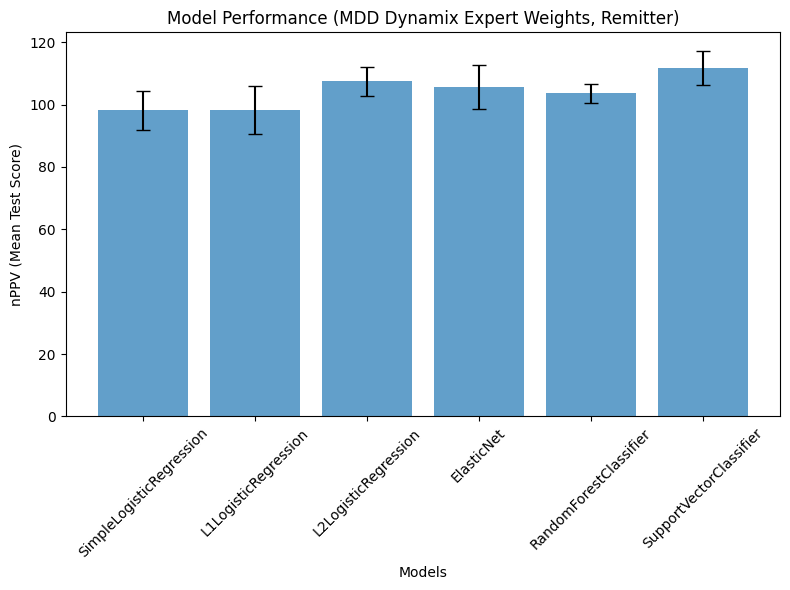

In [117]:
# make summary plot
plt.figure(figsize=(8,6))
n_random_states=5
stderr_scores = np.array(stddev_scores) / np.sqrt(n_random_states)
bars = plt.bar(algorithms, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)

plt.xlabel('Models')
plt.ylabel(f'{eval_metric_cap} (Mean Test Score)')
plt.title(f'Model Performance ({conditions_cap}, {response_var_cap})')
plt.xticks(rotation=45)

# add baseline for accuracy
if eval_metric == "accuracy":
    plt.axhline(y=mean_baseline, color='red', linestyle='--', linewidth=2, label=f'Mean Baseline ({mean_baseline:.2f})')
    plt.legend()

# for bar, mean in zip(bars, mean_scores):
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         height / 2,                # center vertically
#         f"{mean:.3f}",
#         ha='center',
#         va='center',
#         color='black',   
#         fontsize=9,
#     )

plt.tight_layout()
plt.savefig(f"../../figures/{response_var}_{conditions}_{eval_metric}.png", format="png", dpi=300)
plt.show()

### Interpretability

In [ ]:
# file = open(f'../../results/{conditions}/SimpleLogisticRegression_{eval_metric}_{response_var}.save', 'rb')
file = open(f'../../results/{conditions}/L1LogisticRegression_{eval_metric}_{response_var}.save', 'rb')
best_models, test_scores = pickle.load(file)
file.close()

# get best model
top_one_index = np.argsort(test_scores)[-1:][0]  
best_model = best_models[top_one_index]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('std', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

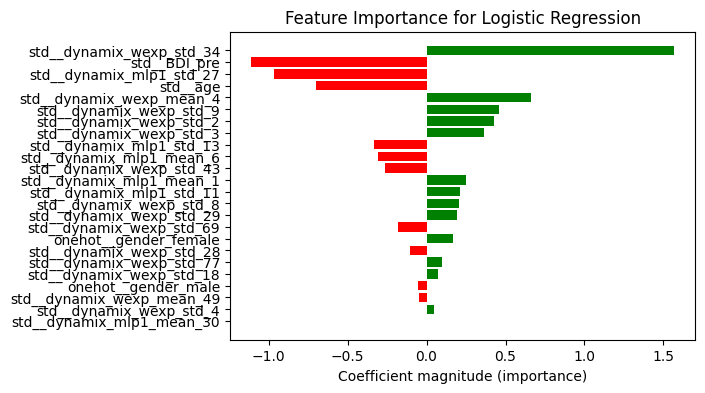

In [99]:
feat_imp = interpretability.get_logreg_feature_importance(best_model)
interpretability.plot_logreg_feature_importance(feat_imp)

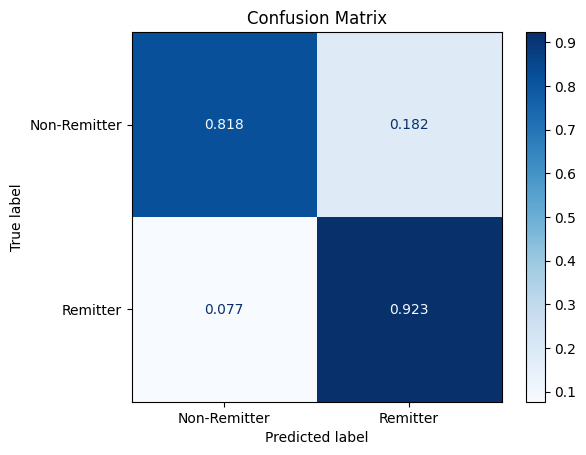

In [100]:
# display confusion matrix
class_labels = [f"Non-{response_var_cap}", response_var_cap]
# plot_confusion_matrix(best_model, X_test, y_test, class_labels)
model = best_model
title = "Confusion Matrix"
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# normalize
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
disp.plot(values_format='.3f', cmap=plt.cm.Blues)
plt.title(title)
plt.show()